# 02 — Exploratory Data Analysis (Member 1)

EDA on the cleaned ML-ready dataset. All graphs are saved under `results/graphs/`.

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
df = pd.read_csv("dataset/cleaned_tv_shows.csv")
GRAPHS = Path("results/graphs"); GRAPHS.mkdir(parents=True, exist_ok=True)
print(df.shape); df.head()

(3000, 8)


,title,release_year,runtime_mins,certificate,primary_genre,key_cast,imdb_rating,success_category
0,The Family Man,2019,42.0,Not Rated,Action,"Manoj Bajpayee, Samantha Akkineni, Priyamani, ...",8.8,High
1,Lucifer,2016,45.0,Not Rated,Crime,"Tom Ellis, Lauren German, Lesley-Ann Brandt, K...",8.1,High
2,The Handmaid's Tale,2017,42.0,Not Rated,Drama,"Elisabeth Moss, Yvonne Strahovski, Joseph Fien...",8.4,High
3,StartUp,2016,60.0,Not Rated,Crime,"Adam Brody, Edi Gathegi, Otmara Marrero, Krist...",8.0,High
4,Game of Thrones,2011,44.0,Not Rated,Action,"Emilia Clarke, Peter Dinklage, Kit Harington, ...",9.3,High


### Rating / target distribution

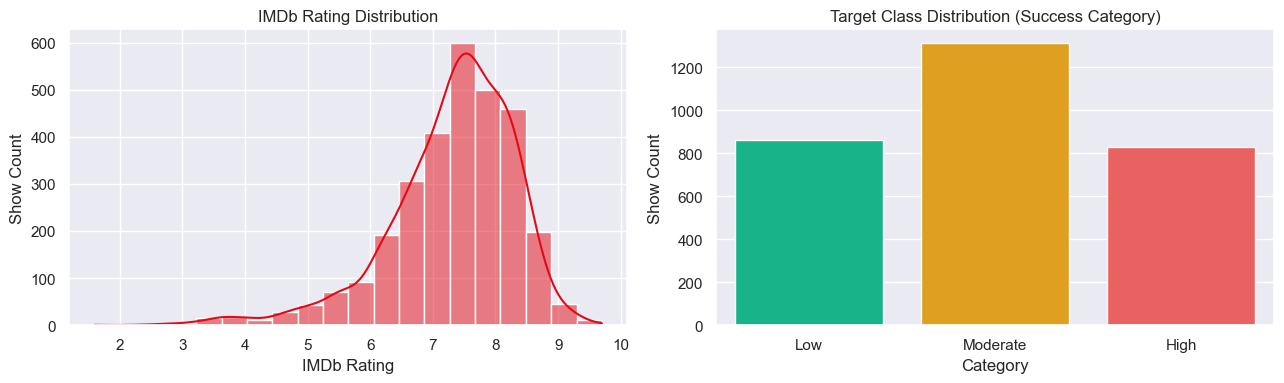

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x="imdb_rating", kde=True, bins=20, color="#E50914", ax=axes[0])
axes[0].set_title("IMDb Rating Distribution"); axes[0].set_xlabel("IMDb Rating"); axes[0].set_ylabel("Show Count")
sns.countplot(data=df, x="success_category", order=["Low", "Moderate", "High"],
              hue="success_category", palette=["#FF4B4B", "#FFAA00", "#00CC96"], legend=False, ax=axes[1])
axes[1].set_title("Target Class Distribution (Success Category)")
axes[1].set_xlabel("Category"); axes[1].set_ylabel("Show Count")
fig.tight_layout(); fig.savefig(GRAPHS / "rating_distribution.png", dpi=150); plt.show()

### Genre distribution

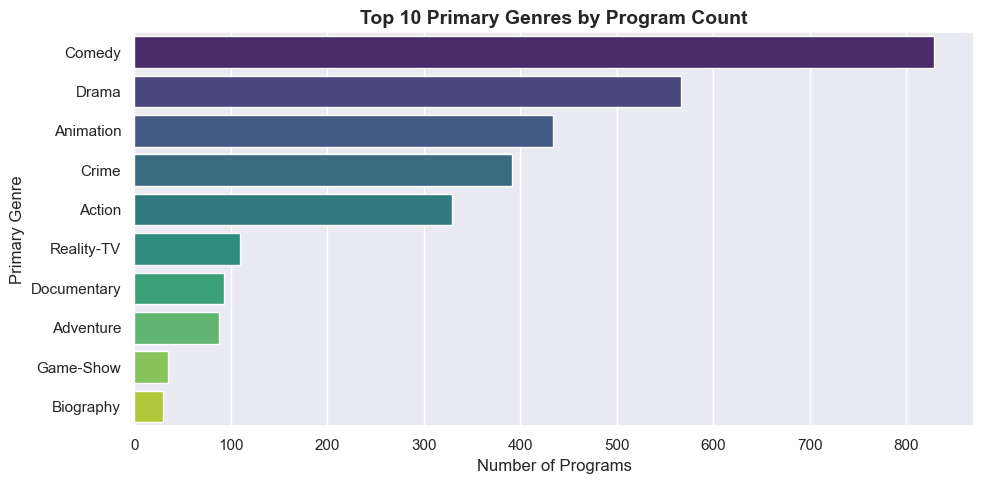

In [3]:
plt.figure(figsize=(10, 5))
top_genres = df["primary_genre"].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette="viridis", legend=False)
plt.title("Top 10 Primary Genres by Program Count", fontsize=14, fontweight="bold")
plt.xlabel("Number of Programs"); plt.ylabel("Primary Genre")
plt.tight_layout(); plt.savefig(GRAPHS / "genre_distribution.png", dpi=150); plt.show()

### Runtime distribution

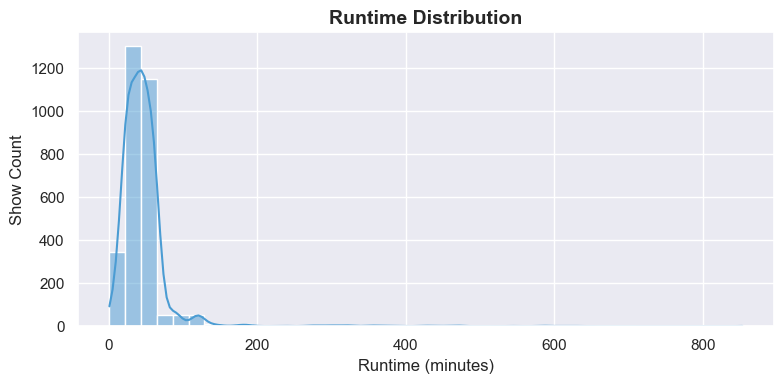

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="runtime_mins", bins=40, color="#4B9CD3", kde=True)
plt.title("Runtime Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Runtime (minutes)"); plt.ylabel("Show Count")
plt.tight_layout(); plt.savefig(GRAPHS / "runtime_distribution.png", dpi=150); plt.show()

### Programs by year

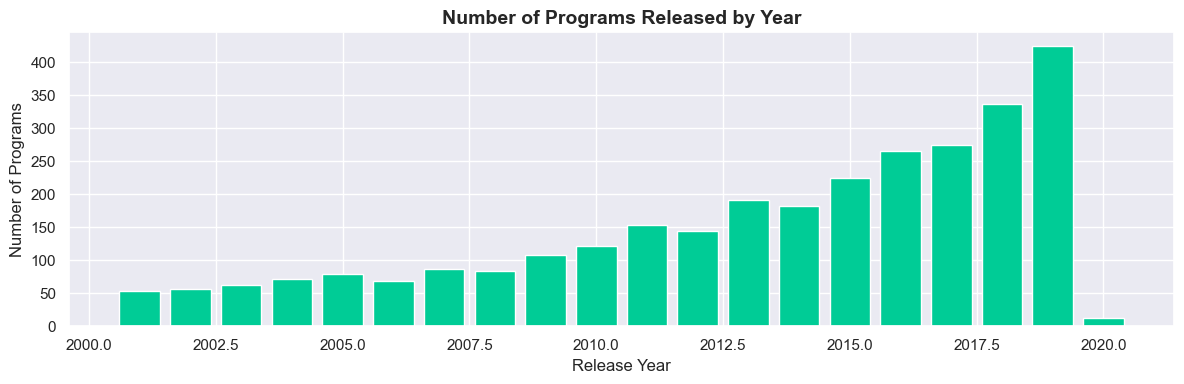

In [5]:
plt.figure(figsize=(12, 4))
year_counts = df["release_year"].value_counts().sort_index()
plt.bar(year_counts.index, year_counts.values, color="#00CC96")
plt.title("Number of Programs Released by Year", fontsize=14, fontweight="bold")
plt.xlabel("Release Year"); plt.ylabel("Number of Programs")
plt.tight_layout(); plt.savefig(GRAPHS / "programs_by_year.png", dpi=150); plt.show()

### Rating vs important numerical features

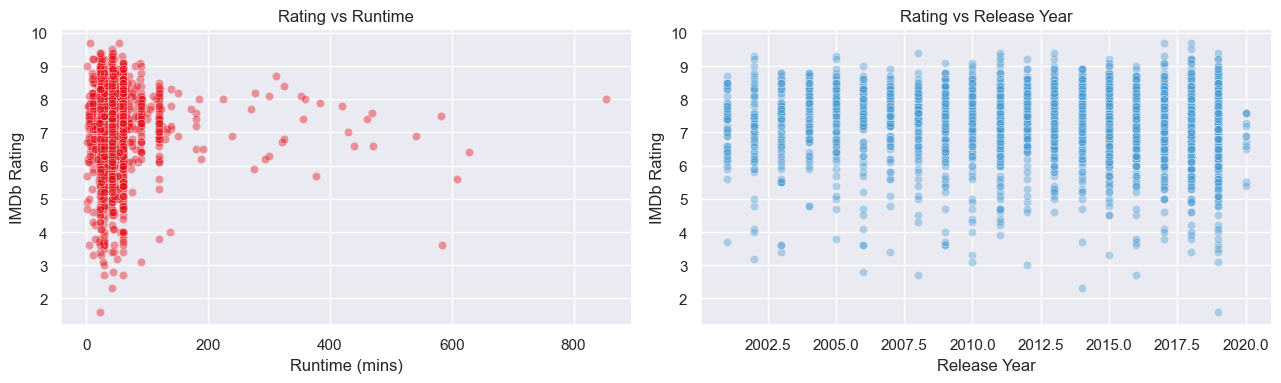

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=df, x="runtime_mins", y="imdb_rating", ax=axes[0], alpha=0.4, color="#E50914")
axes[0].set_title("Rating vs Runtime"); axes[0].set_xlabel("Runtime (mins)"); axes[0].set_ylabel("IMDb Rating")
sns.scatterplot(data=df, x="release_year", y="imdb_rating", ax=axes[1], alpha=0.4, color="#4B9CD3")
axes[1].set_title("Rating vs Release Year"); axes[1].set_xlabel("Release Year"); axes[1].set_ylabel("IMDb Rating")
fig.tight_layout(); fig.savefig(GRAPHS / "rating_vs_numerical.png", dpi=150); plt.show()

### Genre vs rating

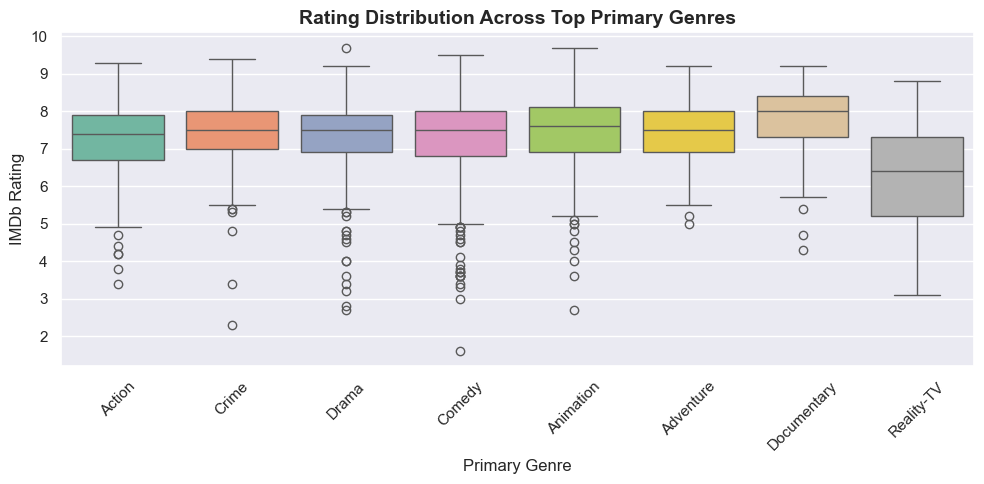

In [7]:
plt.figure(figsize=(10, 5))
top8 = df["primary_genre"].value_counts().head(8).index
sns.boxplot(data=df[df["primary_genre"].isin(top8)], x="primary_genre", y="imdb_rating",
            hue="primary_genre", palette="Set2", legend=False)
plt.title("Rating Distribution Across Top Primary Genres", fontsize=14, fontweight="bold")
plt.xticks(rotation=45); plt.xlabel("Primary Genre"); plt.ylabel("IMDb Rating")
plt.tight_layout(); plt.savefig(GRAPHS / "genre_vs_rating.png", dpi=150); plt.show()

### Numerical correlation heatmap

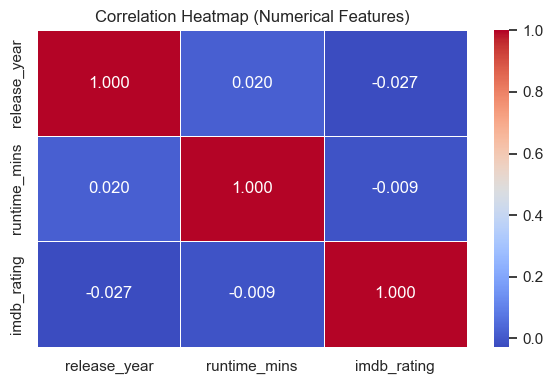

In [8]:
plt.figure(figsize=(6, 4))
corr = df[["release_year", "runtime_mins", "imdb_rating"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout(); plt.savefig(GRAPHS / "correlation_heatmap.png", dpi=150); plt.show()

### Outlier analysis

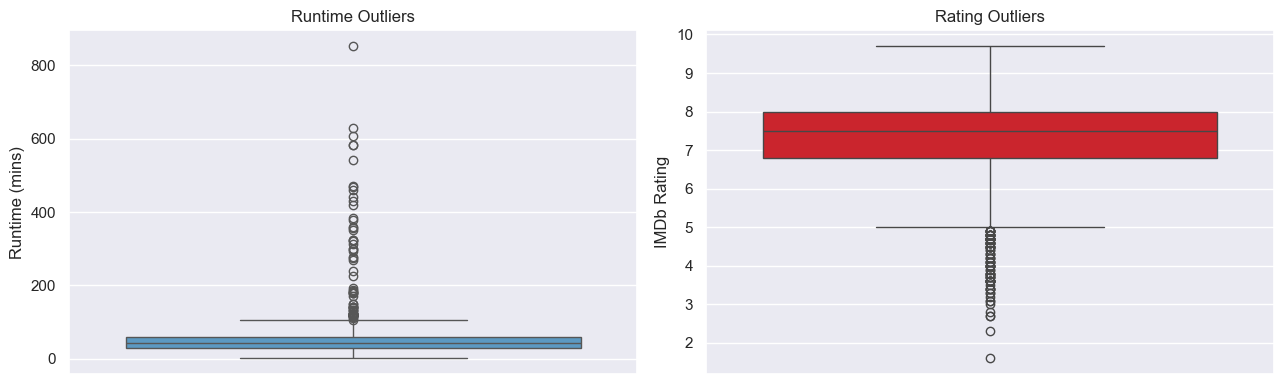

runtime_mins: IQR=30.00, outliers by 1.5*IQR rule = 98
imdb_rating: IQR=1.20, outliers by 1.5*IQR rule = 89


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(y=df["runtime_mins"], color="#4B9CD3", ax=axes[0])
axes[0].set_title("Runtime Outliers"); axes[0].set_ylabel("Runtime (mins)")
sns.boxplot(y=df["imdb_rating"], color="#E50914", ax=axes[1])
axes[1].set_title("Rating Outliers"); axes[1].set_ylabel("IMDb Rating")
fig.tight_layout(); fig.savefig(GRAPHS / "outlier_analysis.png", dpi=150); plt.show()

for col in ["runtime_mins", "imdb_rating"]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
    print(f"{col}: IQR={iqr:.2f}, outliers by 1.5*IQR rule = {n_out}")